# Week 1: Linear Regression Basics

This notebook introduces a complete regression workflow using the California Housing dataset: data inspection, an 80/20 train-test split, ordinary least-squares fitting, regression metrics, and an actual-versus-predicted plot.

## Step 1.1 - Load and Inspect the Dataset

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Create DataFrame for features
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["MedHouseValue"] = housing.target

In [2]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  


In [3]:
print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())

Dataset shape: (20640, 9)
Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseValue']


In [4]:
print("\nDataset info:")
df.info()

print("\nSummary statistics:")
print(df.describe())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.

In [5]:
print("Dataset description:")
print(housing.DESCR[:2000])  # first part of the official dataset description

print("\nFeature names:")
print(housing.feature_names)

print("\nTarget name:")
print("MedHouseValue")

Dataset description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
b

## Step 1.2 - Dataset Fields

### Feature meaning

- **MedInc**: Median income of households in the district
- **HouseAge**: Median house age in the district
- **AveRooms**: Average number of rooms per household
- **AveBedrms**: Average number of bedrooms per household
- **Population**: Total population in the district
- **AveOccup**: Average number of people living in a household
- **Latitude**: Geographic latitude of the district
- **Longitude**: Geographic longitude of the district

### Target variable
- **MedHouseValue**: Median house value of the district

In [6]:
print("Number of rows and columns:", df.shape)
print("Number of input features:", len(housing.feature_names))
print("Target column: MedHouseValue")
print("\nData types:")
print(df.dtypes)

Number of rows and columns: (20640, 9)
Number of input features: 8
Target column: MedHouseValue

Data types:
MedInc           float64
HouseAge         float64
AveRooms         float64
AveBedrms        float64
Population       float64
AveOccup         float64
Latitude         float64
Longitude        float64
MedHouseValue    float64
dtype: object


## Step 2.1 - Train-test split with fixed random seed

In [7]:
from sklearn.model_selection import train_test_split

# Separate input features (X) and target (y)
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTraining set shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set shapes:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X shape: (20640, 8)
y shape: (20640,)

Training set shapes:
X_train: (16512, 8)
y_train: (16512,)

Test set shapes:
X_test: (4128, 8)
y_test: (4128,)


The dataset was divided into input features (`X`) and target values (`y`). 
A train-test split was then performed using `test_size=0.2`, meaning 80% of the data was used for training and 20% for testing. 
A fixed random seed (`random_state=42`) was used to ensure reproducibility of the results.

In [8]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Fit the model on training data
model.fit(X_train, y_train)

model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [9]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept:
-37.023277706064164

Coefficients:
MedInc: 0.44867490966571794
HouseAge: 0.00972425751790552
AveRooms: -0.12332334282795918
AveBedrms: 0.7831449067929721
Population: -2.0296205801455687e-06
AveOccup: -0.0035263184871342865
Latitude: -0.41979248658836066
Longitude: -0.4337080649639881


A Linear Regression model was selected as the first baseline model for the California Housing dataset. The model was trained using the training subset of the data. This step establishes a simple reference model before moving to prediction and performance evaluation.

## Step 3.1 - Predict on the test set

In [10]:
# Predict on the test set
y_pred = model.predict(X_test)

print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [11]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("First 10 actual vs predicted values:")
print(comparison_df.head(10))

First 10 actual vs predicted values:
    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


The trained Linear Regression model was used to predict the target values for the test dataset. The predicted values were then compared with the actual values in order to inspect how closely the model estimates the median house value.

## Step 3.2 - Evaluate the model with regression metrics

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Metrics:
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


In [13]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

Training R²: 0.6126
Test R²    : 0.5758


The model performance was evaluated using standard regression metrics: MAE, MSE, RMSE, and R². These metrics provide complementary information about prediction error and goodness of fit. Lower MAE, MSE, and RMSE values indicate smaller prediction errors, while a higher R² value indicates that the model explains a greater portion of the variation in the target variable.

## Step 3.3 - Visualize actual vs predicted values

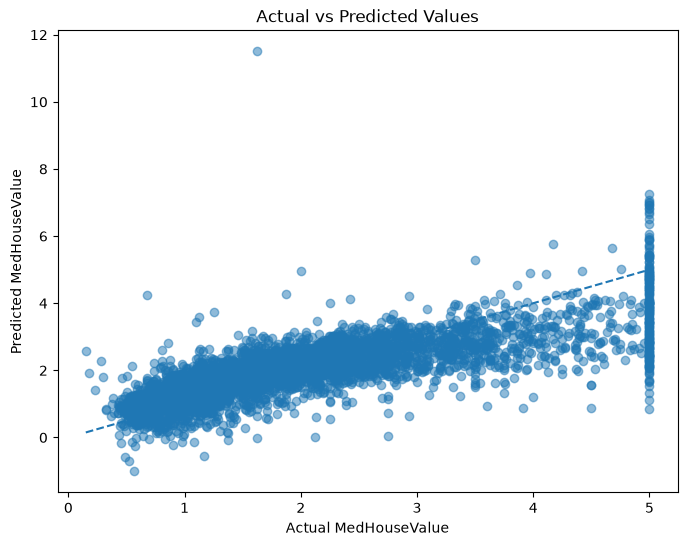

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')

plt.xlabel("Actual MedHouseValue")
plt.ylabel("Predicted MedHouseValue")
plt.title("Actual vs Predicted Values")
plt.show()

A scatter plot was created to compare the actual and predicted median house values for the test dataset. The dashed diagonal line represents perfect predictions. Points close to this line indicate accurate predictions, while points farther away indicate larger errors.

## Interpretation of results

The ordinary linear model provides a useful first baseline. Its test $R^2$ is slightly lower than its training $R^2$, while the actual-versus-predicted plot shows larger errors at some target values. This motivates the regularized and feature-engineered linear models evaluated later in the project.